### KINYUA SEAMAN
#### AI ALGORITHMS - Assigments 1 to 4

**Assignment 1. N-Puzzle Using A**
The Mechanics of A*

A* selects the next state to explore based on the cost function:
    $$f(n) = g(n) + h(n)$$ 
- $g(n)$(Actual Cost): The number of moves taken from the start state to the current state $n$.
- $h(n)$(Heuristic Cost): An estimated cost from the current state to the goal. For the 8-puzzle, the Manhattan Distance is the most effective heuristic.
    - Manhattan Distance: The sum of the vertical and horizontal distances of each tile from its target position.

*0 Represents the empty space*

In [1]:
import heapq

# CONFIGURATION 
GOAL_STATE = (
    (0, 1, 2),
    (3, 4, 5),
    (6, 7, 8)
)

# Start state (Randomly mixed for this example)
START_STATE = (
    (1, 2, 8),
    (5, 0, 6),
    (4, 3, 7)
)

# HELPER FUNCTIONS 

def manhattan_distance(state):
    """
    Heuristic h(n): Calculates the sum of distances of all tiles from their goal positions.
    """
    distance = 0
    for r in range(3):
        for c in range(3):
            val = state[r][c]
            if val != 0:  # Don't calculate distance for the empty tile
                # Find target position of val in GOAL_STATE
                target_r, target_c = divmod(val - 1, 3) 
                distance += abs(r - target_r) + abs(c - target_c)
    return distance

def get_neighbors(state):
    # Returns a list of valid next states by sliding the empty tile (0).
   
    neighbors = []
    
    # Find position of empty tile (0)
    for r in range(3):
        for c in range(3):
            if state[r][c] == 0:
                zero_r, zero_c = r, c
                break
    
    # Possible moves: Up, Down, Left, Right
    moves = [(-1, 0), (1, 0), (0, -1), (0, 1)]
    
    for dr, dc in moves:
        new_r, new_c = zero_r + dr, zero_c + dc
        
        # Check bounds
        if 0 <= new_r < 3 and 0 <= new_c < 3:
            # Create new state (tuple of tuples for immutability/hashing)
            new_state = [list(row) for row in state]
            # Swap 0 with the neighbor
            new_state[zero_r][zero_c], new_state[new_r][new_c] = \
            new_state[new_r][new_c], new_state[zero_r][zero_c]
            neighbors.append(tuple(tuple(row) for row in new_state))
            
    return neighbors

In [2]:
# A* ALGORITHM 

def solve_8_puzzle(start, goal):
    # Priority Queue stores tuples: (f_score, g_score, current_state, path)
    # f_score is first so heapq sorts by it automatically
    pq = []
    start_h = manhattan_distance(start)
    heapq.heappush(pq, (start_h, 0, start, []))
    
    visited = set()
    visited.add(start)
    
    nodes_explored = 0
    
    while pq:
        f, g, current, path = heapq.heappop(pq)
        nodes_explored += 1
        
        if current == goal:
            return path + [current], nodes_explored
        
        for neighbor in get_neighbors(current):
            if neighbor not in visited:
                visited.add(neighbor)
                new_g = g + 1
                new_h = manhattan_distance(neighbor)
                new_f = new_g + new_h
                heapq.heappush(pq, (new_f, new_g, neighbor, path + [current]))
                
    return None, nodes_explored

# EXECUTION

solution_path, nodes = solve_8_puzzle(START_STATE, GOAL_STATE)

if solution_path:
    print(f"Solution found in {len(solution_path) - 1} moves!")
    print(f"Nodes explored: {nodes}\n")
    
    # Display Start and Solution as 3x3 grids
    def print_grid(state, label):
        print(f"{label}:")
        print("+---+---+---+")
        for row in state:
            print("| " + " | ".join(str(x) if x != 0 else ' ' for x in row) + " |")
            print("+---+---+---+")
        print()

    print_grid(solution_path[0], "Start State")
    print_grid(solution_path[-1], "Goal State (Solved)")

else:
    print("No solution found.")

Solution found in 20 moves!
Nodes explored: 39993

Start State:
+---+---+---+
| 1 | 2 | 8 |
+---+---+---+
| 5 |   | 6 |
+---+---+---+
| 4 | 3 | 7 |
+---+---+---+

Goal State (Solved):
+---+---+---+
|   | 1 | 2 |
+---+---+---+
| 3 | 4 | 5 |
+---+---+---+
| 6 | 7 | 8 |
+---+---+---+



**Assignment 2 - EA's or swarm algorithms application**

The Swarm Approach: Ant Colony Optimization (ACO).<br>
ACO mimics how ants find the shortest path to food using pheromone trails.
- Ant: An agent that constructs a valid route.
- Pheromone: A chemical trail left on the "edges" (roads) between cities.
- Heuristic: The physical distance (ants prefer shorter edges naturally).

In [3]:
import numpy as np
import random
import matplotlib.pyplot as plt

# CONFIGURATION 
NUM_CITIES = 15
#NUM_CITIES = 20
MAP_SIZE = 100
NUM_ANTS = 20           # Number of agents (ants) per iteration
ITERATIONS = 100        # How many times the swarm goes out
ALPHA = 1.0             # Pheromone importance (history)
BETA = 2.0              # Distance importance (heuristic)
EVAPORATION_RATE = 0.5  # How fast pheromones disappear (0.0 to 1.0)
Q = 100                 # Pheromone deposit factor

# SETUP: Generate Random Cities
np.random.seed(42)
cities = {i: (np.random.randint(0, MAP_SIZE), np.random.randint(0, MAP_SIZE)) for i in range(NUM_CITIES)}

def distance(city1, city2):
    # Calculates Euclidean distance between two city indices.
    x1, y1 = cities[city1]
    x2, y2 = cities[city2]
    return np.sqrt((x1-x2)**2 + (y1-y2)**2)

# Precompute distance matrix to speed up lookup
dist_matrix = np.zeros((NUM_CITIES, NUM_CITIES))
for i in range(NUM_CITIES):
    for j in range(NUM_CITIES):
        dist_matrix[i][j] = distance(i, j)
        # Avoid division by zero for self-distance
        if i == j: dist_matrix[i][j] = np.inf 

def calculate_route_cost(route):
    # Calculates total distance of a route.
    cost = 0
    for i in range(len(route)):
        u = route[i]
        v = route[(i + 1) % len(route)] # Loop back to start
        cost += dist_matrix[u][v]
    return cost

In [4]:
#ANT COLONY OPTIMIZATION (Swarm)

class AntColonyOptimization:
    def __init__(self):
        # Initialize pheromones on all paths (edges) to a small constant (1.0)
        self.pheromones = np.ones((NUM_CITIES, NUM_CITIES))

    def select_next_city(self, current_city, visited):
        # Decides where an ant goes next based on Pheromone level and Distance.
        probabilities = []
        available_cities = [c for c in range(NUM_CITIES) if c not in visited]
        
        # If all cities visited, no move possible
        if not available_cities:
            return None

        total_prob = 0
        for city in available_cities:
            # Pheromone strength on the edge (History)
            pher = self.pheromones[current_city][city] ** ALPHA
            
            # Visibility/Heuristic: Inverse of distance (Shorter is better)
            # Add small epsilon to avoid division by zero if cities overlap
            dist = (1.0 / (dist_matrix[current_city][city] + 0.0001)) ** BETA
            
            prob = pher * dist
            probabilities.append(prob)
            total_prob += prob
            
        # Normalize probabilities so they sum to 1.0
        probabilities = [p / total_prob for p in probabilities]
        
        # Roulette Wheel Selection
        return np.random.choice(available_cities, p=probabilities)

    def run(self):
        best_global_route = None
        best_global_cost = float('inf')
        
        # History for plotting
        cost_history = []

        for it in range(ITERATIONS):
            all_routes = []
            
            # All Ants Construct Solutions
            for k in range(NUM_ANTS):
                route = [np.random.randint(0, NUM_CITIES)] # Start at a random city
                for _ in range(NUM_CITIES - 1):  # Visit all other cities
                    next_city = self.select_next_city(route[-1], set(route))
                    route.append(next_city)
                
                cost = calculate_route_cost(route)
                all_routes.append((route, cost))
                # Check for new best solution
                if cost < best_global_cost:
                    best_global_cost = cost
                    best_global_route = route
            
            cost_history.append(best_global_cost)

            # Pheromone Evaporation
            # Old trails fade away to prevent getting stuck in local optima
            self.pheromones *= (1 - EVAPORATION_RATE)
            
            # Pheromone Deposit
            # Ants strengthen the paths they took based on how good the path was
            for route, cost in all_routes:
                deposit_amount = Q / cost # Shorter path = More pheromone
                for i in range(NUM_CITIES):
                    u = route[i]
                    v = route[(i+1) % NUM_CITIES]
                    # Update both directions (undirected graph)
                    self.pheromones[u][v] += deposit_amount
                    self.pheromones[v][u] += deposit_amount
            
            if (it + 1) % 10 == 0:
                print(f"Iteration {it+1}/{ITERATIONS}: Best Cost = {best_global_cost:.2f}")

        return best_global_route, best_global_cost, cost_history

# EXECUTION
aco = AntColonyOptimization()
best_route, best_cost, history = aco.run()

print(f"\nFinal Best Route Cost: {best_cost:.2f}")
# Convert all numpy integers to standard strings and join them with arrows
formatted_route = " -> ".join(str(int(city)) for city in best_route)
print(f"Final Route Sequence: {formatted_route}")

Iteration 10/100: Best Cost = 343.69
Iteration 20/100: Best Cost = 340.22
Iteration 30/100: Best Cost = 340.22
Iteration 40/100: Best Cost = 340.22
Iteration 50/100: Best Cost = 340.22
Iteration 60/100: Best Cost = 340.22
Iteration 70/100: Best Cost = 340.22
Iteration 80/100: Best Cost = 340.22
Iteration 90/100: Best Cost = 340.22
Iteration 100/100: Best Cost = 340.22

Final Best Route Cost: 340.22
Final Route Sequence: 13 -> 11 -> 2 -> 14 -> 4 -> 3 -> 5 -> 0 -> 12 -> 1 -> 8 -> 10 -> 7 -> 9 -> 6


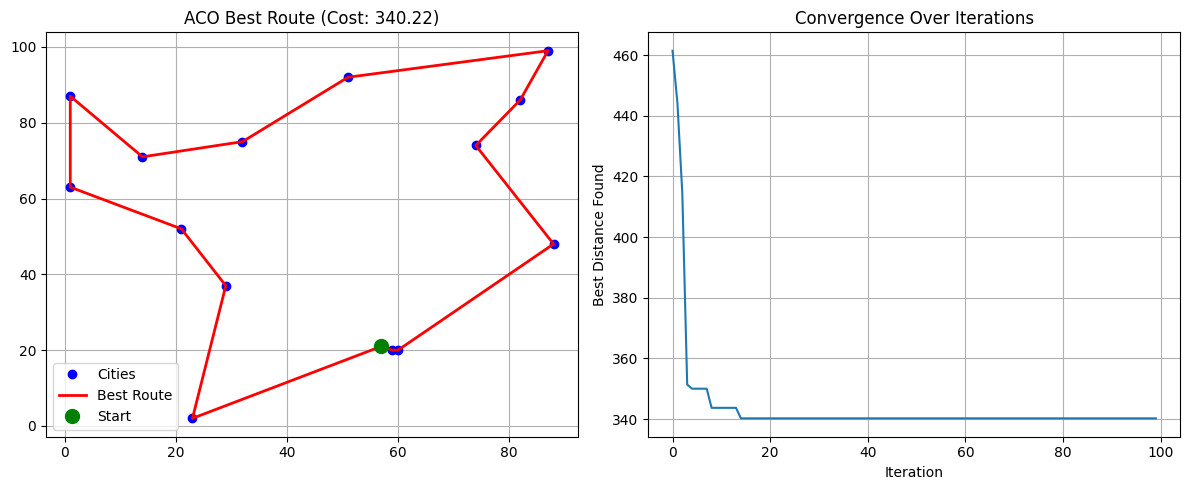

In [5]:
# VISUALIZATION
# Plot the Map and Route
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
# Plot all cities
x_coords = [cities[i][0] for i in range(NUM_CITIES)]
y_coords = [cities[i][1] for i in range(NUM_CITIES)]
plt.plot(x_coords, y_coords, 'bo', label='Cities')

# Plot the path
if best_route:
    route_x = [cities[i][0] for i in best_route] + [cities[best_route[0]][0]]
    route_y = [cities[i][1] for i in best_route] + [cities[best_route[0]][1]]
    plt.plot(route_x, route_y, 'r-', linewidth=2, label='Best Route')
    # Mark start
    plt.plot(route_x[0], route_y[0], 'go', markersize=10, label='Start')

plt.title(f"ACO Best Route (Cost: {best_cost:.2f})")
plt.legend()
plt.grid(True)

# Plot Convergence History
plt.subplot(1, 2, 2)
plt.plot(history)
plt.title("Convergence Over Iterations")
plt.xlabel("Iteration")
plt.ylabel("Best Distance Found")
plt.grid(True)

plt.tight_layout()
plt.show()

**Assignment 3- CSP - sudoku 9*9**

Backtracking with MRV: 
- This implementation uses the MRV heuristic (finding the empty cell with the fewest options) which makes it significantly faster than naive recursion.

Algorithm X with Dancing Links (DLX): As improvement
- Algorithm X solves Exact Cover by selecting rows in a binary matrix. DLX is the implementation technique that uses circular doubly-linked lists to "cover" (remove) and "uncover" (restore) rows and columns in $O(1)$ time. This eliminates the overhead of copying matrices during recursion.

- The Concept: We have a universe of constraints (324 total):
    - Cell Constraints (81): Each of the 81 cells must have a number.
    - Row Constraints (81): Each row must have numbers 1-9.
    - Col Constraints (81): Each column must have numbers 1-9.
    - Box Constraints (81): Each 3x3 box must have numbers 1-9.

In [6]:
# MRV BACKTRACKING SOLVER 

class SudokuBacktracking:
    def __init__(self, board):
        # Create a deep copy to avoid modifying the original input during recursion
        self.board = [row[:] for row in board]
        self.nodes_visited = 0  # Initialize counter

    def find_mrv_cell(self):
        """
        Minimum Remaining Values (MRV) Heuristic:
        Finds the empty cell with the fewest valid options.
        """
        min_options = 10
        best_cell = None
        
        for r in range(9):
            for c in range(9):
                if self.board[r][c] == 0:
                    options = self.count_valid_options(r, c)
                    if options < min_options:
                        min_options = options
                        best_cell = (r, c)
                        # Optimization: 1 is the minimum possible options, so return immediately
                        if min_options == 1: 
                            return best_cell
        return best_cell

    def count_valid_options(self, row, col):
        count = 0
        for num in range(1, 10):
            if self.is_valid(row, col, num):
                count += 1
        return count

    def is_valid(self, row, col, num):
        # Row & Col Check
        for i in range(9):
            if self.board[row][i] == num or self.board[i][col] == num:
                return False
        # Box Check
        start_row, start_col = 3 * (row // 3), 3 * (col // 3)
        for i in range(3):
            for j in range(3):
                if self.board[i + start_row][j + start_col] == num:
                    return False
        return True

    def solve(self):
        self.nodes_visited += 1 # Increment node counter
        
        empty_loc = self.find_mrv_cell()
        if not empty_loc:
            return True # No empty cells left = Solved
        
        row, col = empty_loc
        for num in range(1, 10):
            if self.is_valid(row, col, num):
                self.board[row][col] = num
                if self.solve():
                    return True
                self.board[row][col] = 0 # Backtrack
        return False

In [7]:
# Algorithm X with Dancing Links (DLX)

class DLXNode:
    def __init__(self, col_header=None):
        self.left = self.right = self.up = self.down = self
        self.column = col_header
        self.row_id = None 

class ColumnNode(DLXNode):
    def __init__(self, name):
        super().__init__()
        self.size = 0
        self.name = name
        self.column = self

class SudokuDLX:
    def __init__(self, board):
        self.header = ColumnNode("header")
        self.columns = []
        self.solution = [] # Stack stores NODES now, not tuples
        self.result_board = [row[:] for row in board]
        self.original_board = board
        self.nodes_visited = 0 
        self.build_cover_matrix()

    def build_cover_matrix(self):
        for i in range(324):
            col = ColumnNode(i)
            col.right = self.header
            col.left = self.header.left
            self.header.left.right = col
            self.header.left = col
            self.columns.append(col)

        for r in range(9):
            for c in range(9):
                val = self.original_board[r][c]
                start = val if val != 0 else 1
                end = val + 1 if val != 0 else 10
                for num in range(start, end):
                    self.add_dlx_row(r, c, num)

    def add_dlx_row(self, r, c, num):
        box_idx = (r // 3) * 3 + (c // 3)
        constraint_indices = [
            r * 9 + c,                              
            81 + r * 9 + (num - 1),                 
            162 + c * 9 + (num - 1),                
            243 + box_idx * 9 + (num - 1)           
        ]
        
        first_node = None
        for idx in constraint_indices:
            col_node = self.columns[idx]
            new_node = DLXNode(col_node)
            new_node.row_id = (r, c, num)
            
            new_node.down = col_node
            new_node.up = col_node.up
            col_node.up.down = new_node
            col_node.up = new_node
            col_node.size += 1
            
            if first_node:
                new_node.left = first_node.left
                new_node.right = first_node
                first_node.left.right = new_node
                first_node.left = new_node
            else:
                first_node = new_node

    def cover(self, col):
        col.right.left = col.left
        col.left.right = col.right
        i = col.down
        while i != col:
            j = i.right
            while j != i:
                j.down.up = j.up
                j.up.down = j.down
                j.column.size -= 1
                j = j.right
            i = i.down

    def uncover(self, col):
        i = col.up
        while i != col:
            j = i.left
            while j != i:
                j.column.size += 1
                j.down.up = j
                j.up.down = j
                j = j.left
            i = i.up
        col.right.left = col
        col.left.right = col

    def search(self):
        self.nodes_visited += 1
        
        if self.header.right == self.header:
            return True
        
        # Heuristic: Choose column with smallest size
        c = self.header.right
        min_size = float('inf')
        chosen_col = None
        while c != self.header:
            if c.size < min_size:
                min_size = c.size
                chosen_col = c
            c = c.right
        
        self.cover(chosen_col)
        
        r = chosen_col.down
        while r != chosen_col:
            # FIX: Store the NODE object, not the tuple
            self.solution.append(r)
            
            j = r.right
            while j != r:
                self.cover(j.column)
                j = j.right
                
            if self.search():
                return True
            
            # Backtrack
            r = self.solution.pop() # Retrieves the NODE
            j = r.left              # .left works because r is a DLXNode
            while j != r:
                self.uncover(j.column)
                j = j.left
            r = r.down
            
        self.uncover(chosen_col)
        return False

    def solve(self):
        if self.search():
            # FIX: Extract tuple from the node here
            for node in self.solution:
                r, c, num = node.row_id
                self.result_board[r][c] = num
            return True
        return False

BENCHMARK: 'AI Escargot' (Hard Difficulty)
Solving with both algorithms...

1. MRV Backtracking:
   - Status: Solved
   - Time:   0.016613 seconds
   - Nodes Visited:  218

2. Algorithm X (DLX):
   - Status: Solved
   - Time:   0.001656 seconds
   - Nodes Visited:  169

 CONCLUSION
DLX was 10.03x faster than MRV Backtracking.


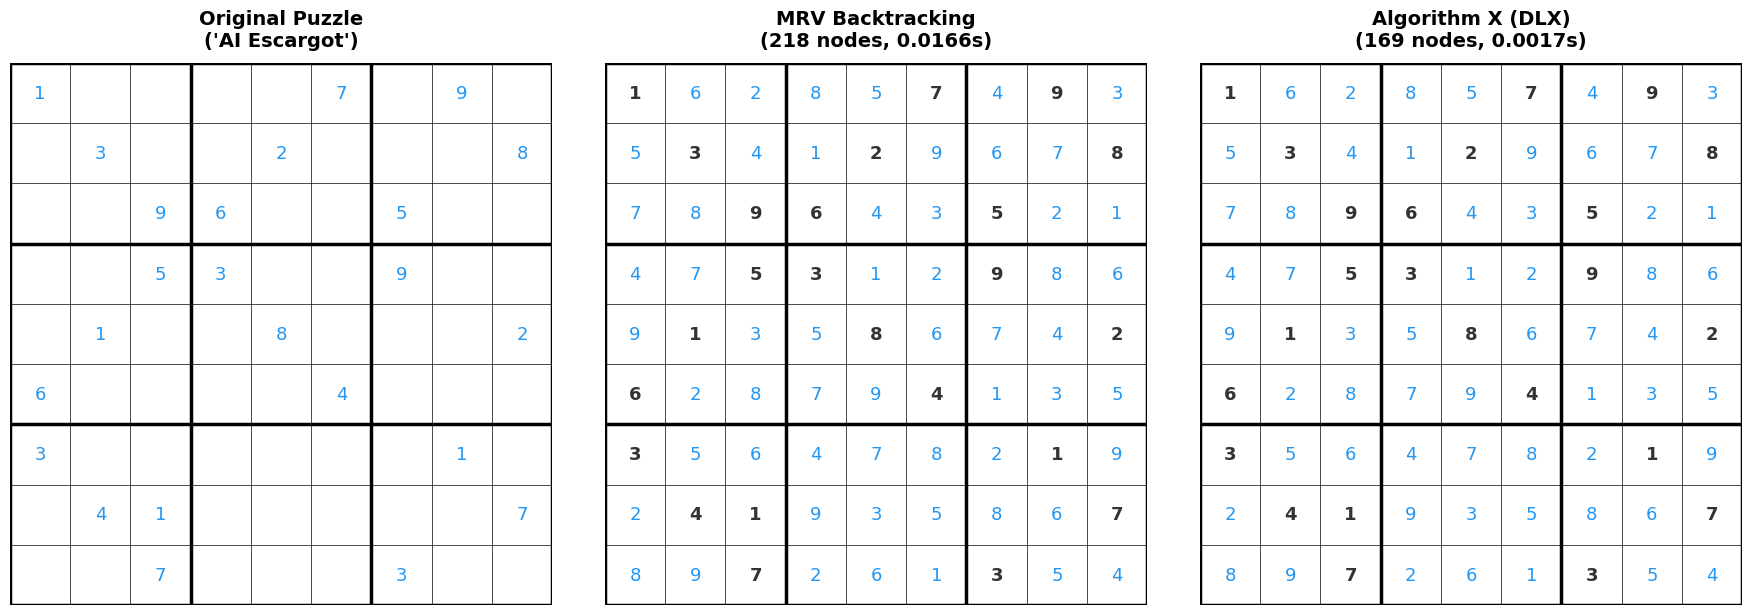

In [8]:
import time, copy

# "AI Escargot" - A notoriously difficult puzzle
HARD_GRID = [
    [1, 0, 0, 0, 0, 7, 0, 9, 0],
    [0, 3, 0, 0, 2, 0, 0, 0, 8],
    [0, 0, 9, 6, 0, 0, 5, 0, 0],
    [0, 0, 5, 3, 0, 0, 9, 0, 0],
    [0, 1, 0, 0, 8, 0, 0, 0, 2],
    [6, 0, 0, 0, 0, 4, 0, 0, 0],
    [3, 0, 0, 0, 0, 0, 0, 1, 0],
    [0, 4, 1, 0, 0, 0, 0, 0, 7],
    [0, 0, 7, 0, 0, 0, 3, 0, 0]
]

print(f"BENCHMARK: 'AI Escargot' (Hard Difficulty)")
print("Solving with both algorithms...\n")

# Test 1: MRV Backtracking 
# Use copy to ensure fresh board
mrv_solver = SudokuBacktracking([row[:] for row in HARD_GRID])
start_time = time.perf_counter()
mrv_success = mrv_solver.solve()
end_time = time.perf_counter()
mrv_duration = end_time - start_time

print(f"1. MRV Backtracking:")
print(f"   - Status: {'Solved' if mrv_success else 'Failed'}")
print(f"   - Time:   {mrv_duration:.6f} seconds")
print(f"   - Nodes Visited:  {mrv_solver.nodes_visited}")

# Test 2: Dancing Links (DLX)
dlx_solver = SudokuDLX([row[:] for row in HARD_GRID])
start_time = time.perf_counter()
dlx_success = dlx_solver.solve()
end_time = time.perf_counter()
dlx_duration = end_time - start_time

print(f"\n2. Algorithm X (DLX):")
print(f"   - Status: {'Solved' if dlx_success else 'Failed'}")
print(f"   - Time:   {dlx_duration:.6f} seconds")
print(f"   - Nodes Visited:  {dlx_solver.nodes_visited}")

# Conclusion 
if dlx_duration > 0:
    speedup = mrv_duration / dlx_duration
    print(f"\n CONCLUSION")
    print(f"DLX was {speedup:.2f}x faster than MRV Backtracking.")
else:
    print("\nDLX was too fast to measure speedup accurately!")

import matplotlib.pyplot as plt
import numpy as np

def draw_sudoku(ax, board, title, original=None):
    """Draw a Sudoku grid on a matplotlib Axes."""
    ax.set_xlim(0, 9)
    ax.set_ylim(0, 9)
    ax.set_aspect('equal')
    ax.set_title(title, fontsize=14, fontweight='bold', pad=12)
    ax.axis('off')

    # Draw cell values
    for r in range(9):
        for c in range(9):
            val = board[r][c]
            if val != 0:
                # Color: blue for original clues, green for solved cells
                if original and original[r][c] != 0:
                    color = '#333333'
                    weight = 'bold'
                else:
                    color = '#2196F3'
                    weight = 'normal'
                ax.text(c + 0.5, 8.5 - r, str(val),
                        ha='center', va='center', fontsize=13,
                        color=color, fontweight=weight)

    # Draw grid lines
    for i in range(10):
        lw = 2.5 if i % 3 == 0 else 0.5
        ax.plot([i, i], [0, 9], 'k-', linewidth=lw)
        ax.plot([0, 9], [i, i], 'k-', linewidth=lw)

# --- Plot ---
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 1. Original puzzle
draw_sudoku(axes[0], HARD_GRID, "Original Puzzle\n('AI Escargot')")

# 2. MRV Backtracking solution
draw_sudoku(axes[1], mrv_solver.board, f"MRV Backtracking\n({mrv_solver.nodes_visited} nodes, {mrv_duration:.4f}s)", original=HARD_GRID)

# 3. DLX solution
draw_sudoku(axes[2], dlx_solver.result_board, f"Algorithm X (DLX)\n({dlx_solver.nodes_visited} nodes, {dlx_duration:.4f}s)", original=HARD_GRID)

plt.tight_layout()
plt.show()


**Assignment 4 - Basic Minimax vs. Alpha-Beta Pruning**

Both algorithms act as the "brain" for an AI player. They look ahead into the future to determine the optimal move.
- Minimax: This is a brute-force approach. It explores every possible future game state until the end of the game (win, loss, or draw). It constructs a full game tree. If the game is in state A, it looks at all children, then all grandchildren, etc., regardless of how bad a move might be.
    - Behavior: Optimal but slow.
- Alpha-Beta Pruning: This is an optimization of Minimax. It stops evaluating a move as soon as it finds out that the move is worse than a previously examined option. It "prunes" (cuts off) branches of the tree that are irrelevant to the final decision.
    - Behavior: Optimal and fast.

In [9]:
import math

class TicTacToeAI:
    def __init__(self):
        self.nodes_explored = 0

    # Helper Functions
    def check_winner(self, board):
        # Rows, Cols, Diagonals
        lines = [
            (0, 1, 2), (3, 4, 5), (6, 7, 8),  # Rows
            (0, 3, 6), (1, 4, 7), (2, 5, 8),  # Cols
            (0, 4, 8), (2, 4, 6)              # Diagonals
        ]
        for a, b, c in lines:
            if board[a] == board[b] == board[c] and board[a] != ' ':
                return board[a]
        if ' ' not in board:
            return 'Draw'
        return None

    # Basic Minimax
    def minimax(self, board, depth, is_maximizing):
        self.nodes_explored += 1
        result = self.check_winner(board)
        
        # Base cases: return score
        if result == 'X': return 10 - depth  # Prefer faster wins
        if result == 'O': return -10 + depth # Prefer slower losses
        if result == 'Draw': return 0

        if is_maximizing: # AI is 'X'
            best_score = -math.inf
            for i in range(9):
                if board[i] == ' ':
                    board[i] = 'X'
                    score = self.minimax(board, depth + 1, False)
                    board[i] = ' ' # Undo move
                    best_score = max(score, best_score)
            return best_score
        else: # Opponent is 'O'
            best_score = math.inf
            for i in range(9):
                if board[i] == ' ':
                    board[i] = 'O'
                    score = self.minimax(board, depth + 1, True)
                    board[i] = ' ' # Undo move
                    best_score = min(score, best_score)
            return best_score

    # Minimax with Alpha-Beta Pruning
    def minimax_ab(self, board, depth, alpha, beta, is_maximizing):
        self.nodes_explored += 1
        result = self.check_winner(board)
        
        if result == 'X': return 10 - depth
        if result == 'O': return -10 + depth
        if result == 'Draw': return 0

        if is_maximizing:
            best_score = -math.inf
            for i in range(9):
                if board[i] == ' ':
                    board[i] = 'X'
                    score = self.minimax_ab(board, depth + 1, alpha, beta, False)
                    board[i] = ' '
                    best_score = max(score, best_score)
                    alpha = max(alpha, score)
                    if beta <= alpha:
                        break # Prune!
            return best_score
        else:
            best_score = math.inf
            for i in range(9):
                if board[i] == ' ':
                    board[i] = 'O'
                    score = self.minimax_ab(board, depth + 1, alpha, beta, True)
                    board[i] = ' '
                    best_score = min(score, best_score)
                    beta = min(beta, score)
                    if beta <= alpha:
                        break # Prune!
            return best_score

    # Wrapper to find the Best Move
    def get_best_move(self, board, algorithm='basic'):
        self.nodes_explored = 0
        best_score = -math.inf
        best_move = -1
        
        # Iterate through all available moves for the root state
        for i in range(9):
            if board[i] == ' ':
                board[i] = 'X' # Make move
                
                if algorithm == 'basic':
                    score = self.minimax(board, 0, False)
                else:
                    score = self.minimax_ab(board, 0, -math.inf, math.inf, False)
                
                board[i] = ' ' # Undo move
                
                if score > best_score:
                    best_score = score
                    best_move = i
                    
        return best_move, self.nodes_explored

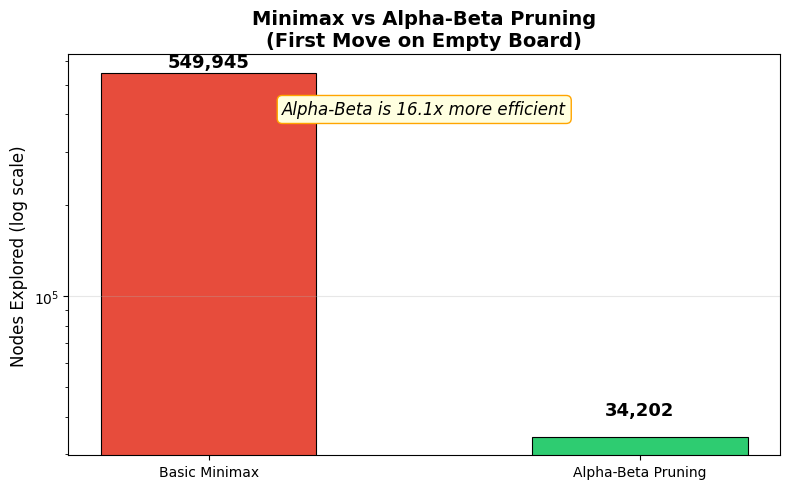

In [12]:
# Simulation Code
# Visualization: Nodes Explored Comparison
import matplotlib.pyplot as plt

ai = TicTacToeAI()
empty_board = [' '] * 9

move_basic, nodes_basic = ai.get_best_move(empty_board, 'basic')
move_ab, nodes_ab = ai.get_best_move(empty_board, 'alpha_beta')

fig, ax = plt.subplots(figsize=(8, 5))

algorithms = ['Basic Minimax', 'Alpha-Beta Pruning']
nodes = [nodes_basic, nodes_ab]
colors = ['#e74c3c', '#2ecc71']

bars = ax.bar(algorithms, nodes, color=colors, width=0.5, edgecolor='black', linewidth=0.8)

# Add value labels on bars
for bar, val in zip(bars, nodes):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5000,
            f'{val:,}', ha='center', va='bottom', fontweight='bold', fontsize=13)

ax.set_ylabel('Nodes Explored', fontsize=12)
ax.set_title('Minimax vs Alpha-Beta Pruning\n(First Move on Empty Board)', fontsize=14, fontweight='bold')
ax.set_yscale('log')
ax.set_ylabel('Nodes Explored (log scale)', fontsize=12)
ax.grid(axis='y', alpha=0.3)

# Add efficiency annotation
speedup = nodes_basic / nodes_ab
ax.annotate(f'Alpha-Beta is {speedup:.1f}x more efficient',
            xy=(0.5, 0.85), xycoords='axes fraction',
            ha='center', fontsize=12, style='italic',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', edgecolor='orange'))

plt.tight_layout()
plt.show()


In [11]:
# Play a Full Game (AI vs AI)

def print_board(board):
    print("+---+---+---+")
    for i in range(3):
        row = board[i*3 : i*3+3]
        print("| " + " | ".join(c if c != ' ' else ' ' for c in row) + " |")
        print("+---+---+---+")

print("\n Full Game Simulation (Alpha-Beta vs Alpha-Beta)\n")
board = [' '] * 9
current_turn = 'X'
steps = 0

while True:
    winner = ai.check_winner(board)
    if winner:
        print(f"Game Over! Result: {winner}")
        print(f"Total turns played: {steps}\n")
        print("Final Board:")
        print_board(board)
        break
    
    is_max = (current_turn == 'X')
    best_val = -math.inf if is_max else math.inf
    best_move = -1
    
    for i in range(9):
        if board[i] == ' ':
            board[i] = current_turn
            val = ai.minimax_ab(board, 0, -math.inf, math.inf, not is_max)
            board[i] = ' '
            
            if is_max and val > best_val:
                best_val = val
                best_move = i
            elif not is_max and val < best_val:
                best_val = val
                best_move = i

    board[best_move] = current_turn
    steps += 1
    current_turn = 'O' if current_turn == 'X' else 'X'



 Full Game Simulation (Alpha-Beta vs Alpha-Beta)

Game Over! Result: Draw
Total turns played: 9

Final Board:
+---+---+---+
| X | X | O |
+---+---+---+
| O | O | X |
+---+---+---+
| X | O | X |
+---+---+---+
